In [3]:
# Uncomment if needed
!pip install -q missingno scipy

In [4]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from scipy.stats import chi2_contingency

from google.colab import drive

# Plot style
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [5]:
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
PROJECT_DIR="/content/drive/MyDrive/Ghana_Dropout_Project"

FIGURE_DIR=f"{PROJECT_DIR}/figures"

os.makedirs(FIGURE_DIR,exist_ok=True)

In [7]:
df=pd.read_csv(f"{PROJECT_DIR}/cleaned_data.csv")

print(df.shape)

df.head()

(1000, 41)


,school_code,geographic_zone,school_type,data_source,gender,age_at_start_of_academic_year,class_level,grade_repetition_count,term_1_attendance,term_2_attendance,...,school_enjoyment,missed_school_for_choreswork,missed_school_due_to_illness,barriers_to_regular_attendance,family_income_level,parent_attends_school_events,behaviour_warnings_punishments,class_participation,extracurricular_activities,dropout_label
0,KNU_JHS,Peri-urban,Public,Questionnaire,Male,10.0,JHS1,0,85.0,82.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,Medium,Sometimes,Never,5.0,1 activity,0
1,KNU_JHS,Peri-urban,Public,Questionnaire,Male,11.0,JHS1,0,87.0,79.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,Medium,Rarely,Once,2.0,2 activities,0
2,KNU_JHS,Peri-urban,Public,Questionnaire,Male,10.0,JHS1,0,70.0,79.0,...,1.0,Yes,"Yes, more than once",Health problems,Medium,Sometimes,Never,5.0,2 activities,0
3,KNU_JHS,Peri-urban,Public,Questionnaire,Female,12.0,JHS1,0,80.0,83.0,...,4.0,No,"Yes, once",Nothing-come regularly,High,Often,Never,4.0,2 activities,0
4,KNU_JHS,Peri-urban,Public,Questionnaire,Female,10.0,JHS1,0,77.0,80.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,High,Sometimes,Never,4.0,1 activity,0


In [8]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

DATASET OVERVIEW
Rows: 1000
Columns: 41


,school_code,geographic_zone,school_type,data_source,gender,age_at_start_of_academic_year,class_level,grade_repetition_count,term_1_attendance,term_2_attendance,...,school_enjoyment,missed_school_for_choreswork,missed_school_due_to_illness,barriers_to_regular_attendance,family_income_level,parent_attends_school_events,behaviour_warnings_punishments,class_participation,extracurricular_activities,dropout_label
0,KNU_JHS,Peri-urban,Public,Questionnaire,Male,10.0,JHS1,0,85.0,82.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,Medium,Sometimes,Never,5.0,1 activity,0
1,KNU_JHS,Peri-urban,Public,Questionnaire,Male,11.0,JHS1,0,87.0,79.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,Medium,Rarely,Once,2.0,2 activities,0
2,KNU_JHS,Peri-urban,Public,Questionnaire,Male,10.0,JHS1,0,70.0,79.0,...,1.0,Yes,"Yes, more than once",Health problems,Medium,Sometimes,Never,5.0,2 activities,0
3,KNU_JHS,Peri-urban,Public,Questionnaire,Female,12.0,JHS1,0,80.0,83.0,...,4.0,No,"Yes, once",Nothing-come regularly,High,Often,Never,4.0,2 activities,0
4,KNU_JHS,Peri-urban,Public,Questionnaire,Female,10.0,JHS1,0,77.0,80.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,High,Sometimes,Never,4.0,1 activity,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   school_code                      1000 non-null   object 
 1   geographic_zone                  1000 non-null   object 
 2   school_type                      1000 non-null   object 
 3   data_source                      1000 non-null   object 
 4   gender                           1000 non-null   object 
 5   age_at_start_of_academic_year    1000 non-null   float64
 6   class_level                      1000 non-null   object 
 7   grade_repetition_count           1000 non-null   object 
 8   term_1_attendance                1000 non-null   float64
 9   term_2_attendance                999 non-null    float64
 10  term_3_attendance                1000 non-null   float64
 11  average_attendance               1000 non-null   float64
 12  english_exam_score   

In [10]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school_code,1000,4,WEWE,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geographic_zone,1000,2,Rural,579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
school_type,1000,2,Public,908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_source,1000,2,Both,924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1000,2,Male,524,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_at_start_of_academic_year,1000.0,NaN,NaN,NaN,11.2647,2.4146,5.0,10.0,12.0,13.0,15.3
class_level,1000,5,JHS2,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grade_repetition_count,1000,20,0,680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
term_1_attendance,1000.0,NaN,NaN,NaN,80.7466,16.493799,20.0,77.0,85.0,90.0,100.5
term_2_attendance,999.0,NaN,NaN,NaN,82.962563,13.922933,10.0,77.8,86.0,92.0,102.9


In [11]:
missing=df.isnull().sum()

missing=missing[missing>0]

missing.sort_values(ascending=False)

,0
extracurricular_activities,249
daily_study_hours_at_home,32
no_of_siblings_in_school,9
class_participation,2
term_2_attendance,1


<Figure size 1200x600 with 0 Axes>

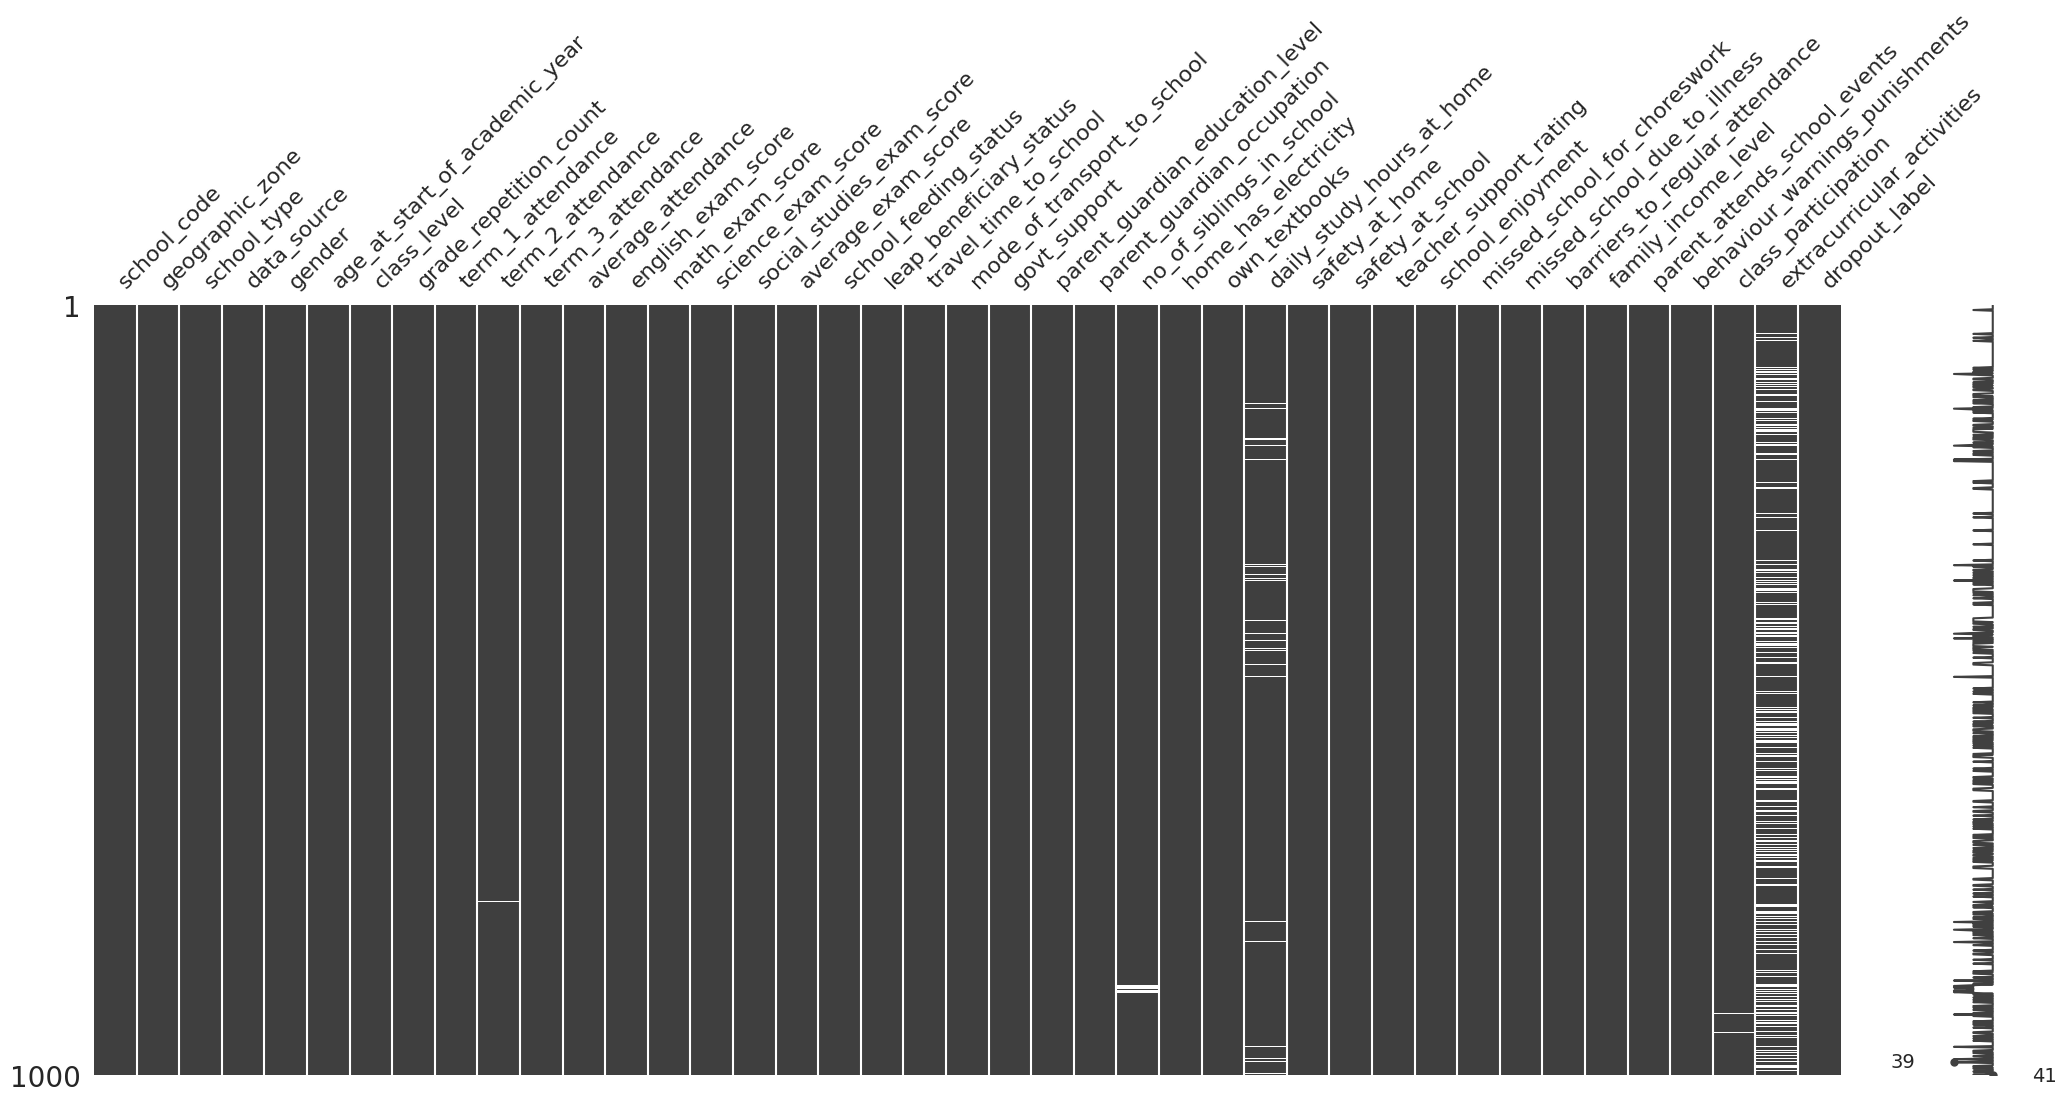

In [12]:
plt.figure(figsize=(12,6))

msno.matrix(df)

plt.savefig(f"{FIGURE_DIR}/missing_values.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [13]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 56


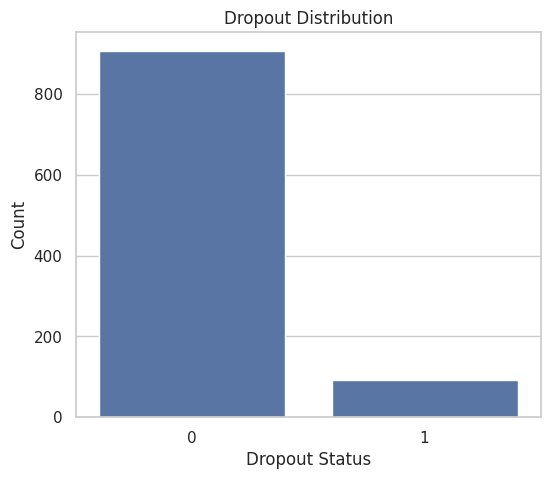

In [14]:
TARGET="dropout_label"

plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x=TARGET)

plt.title("Dropout Distribution")

plt.xlabel("Dropout Status")

plt.ylabel("Count")

plt.savefig(f"{FIGURE_DIR}/target_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [15]:
target_percentage=(
    df[TARGET]
    .value_counts(normalize=True)
    *100
)

display(target_percentage)

,proportion
dropout_label,
0,90.8
1,9.2


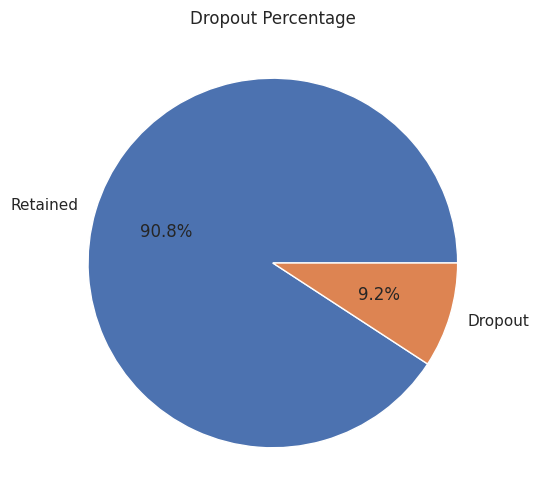

In [16]:
plt.figure(figsize=(6,6))

df[TARGET].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Retained","Dropout"]
)

plt.ylabel("")

plt.title("Dropout Percentage")

plt.savefig(f"{FIGURE_DIR}/dropout_percentage.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [17]:
numeric=df.select_dtypes(include=np.number).columns.tolist()

numeric.remove(TARGET)

numeric

['age_at_start_of_academic_year',
 'term_1_attendance',
 'term_2_attendance',
 'term_3_attendance',
 'average_attendance',
 'english_exam_score',
 'math_exam_score',
 'science_exam_score',
 'average_exam_score',
 'school_feeding_status',
 'home_has_electricity',
 'safety_at_home',
 'safety_at_school',
 'teacher_support_rating',
 'school_enjoyment',
 'class_participation']

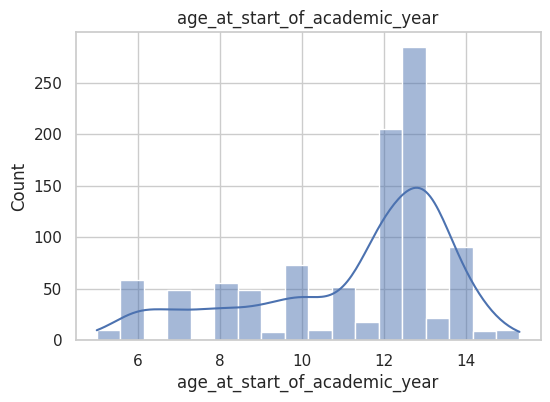

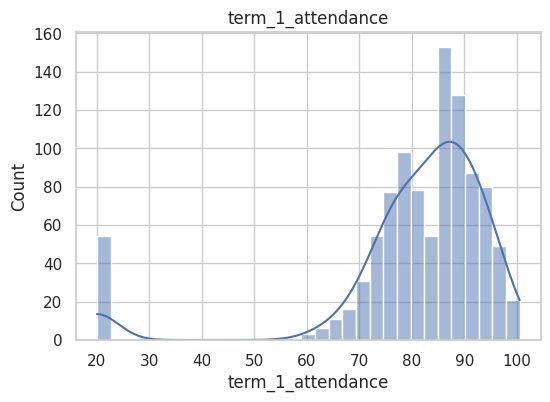

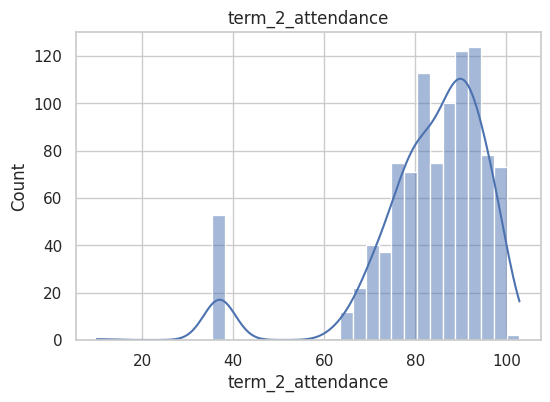

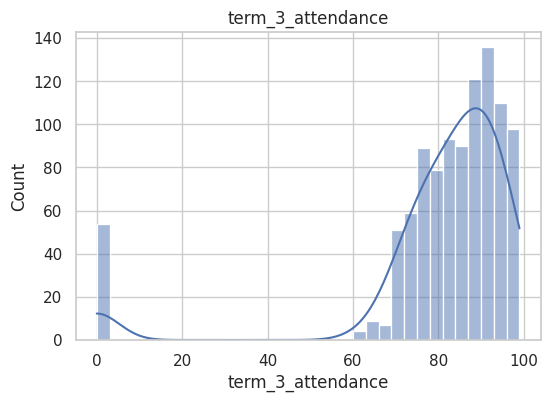

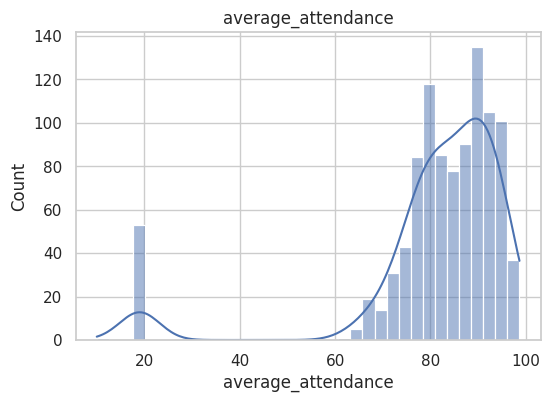

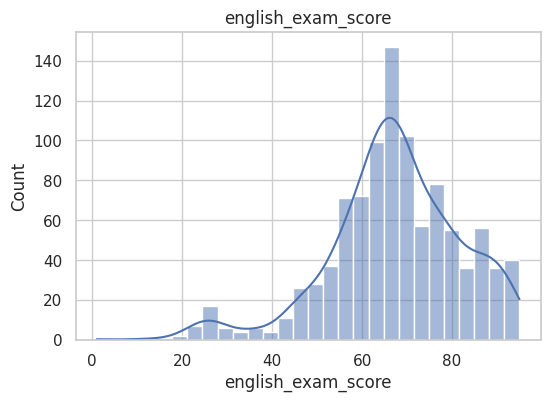

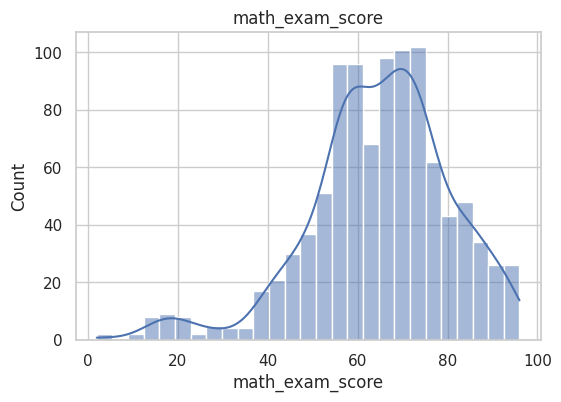

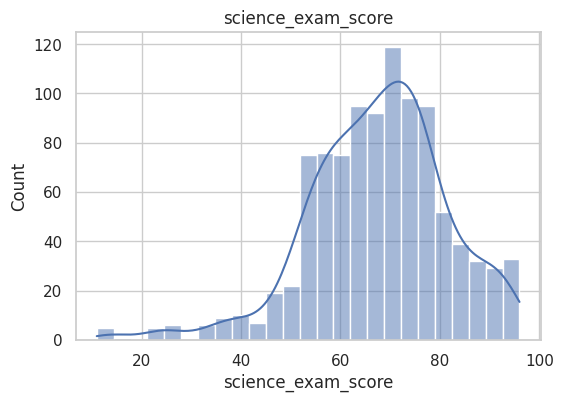

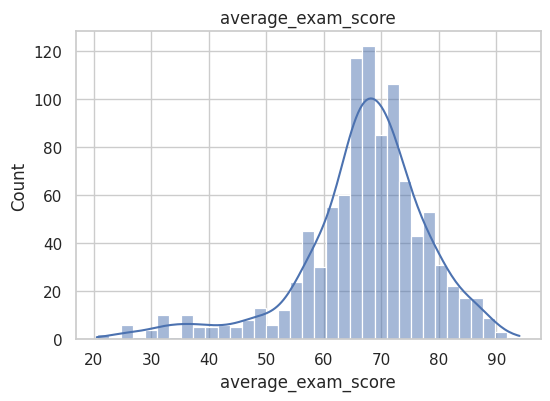

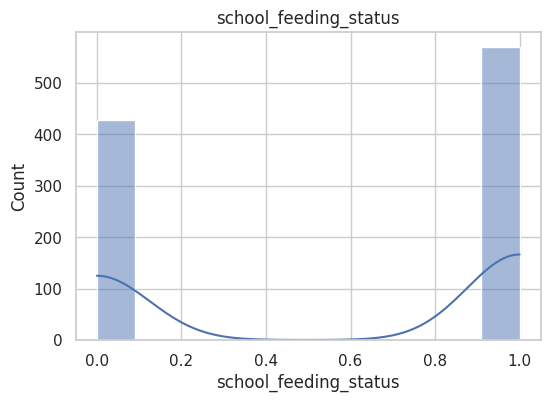

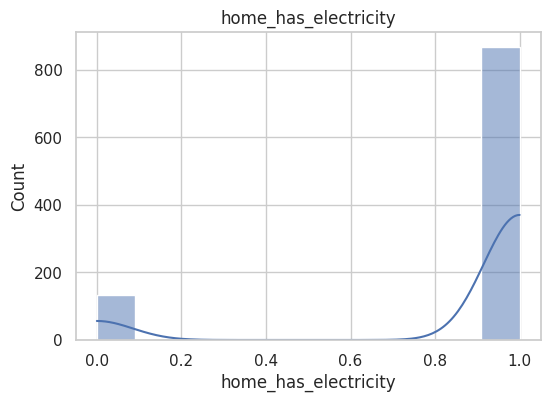

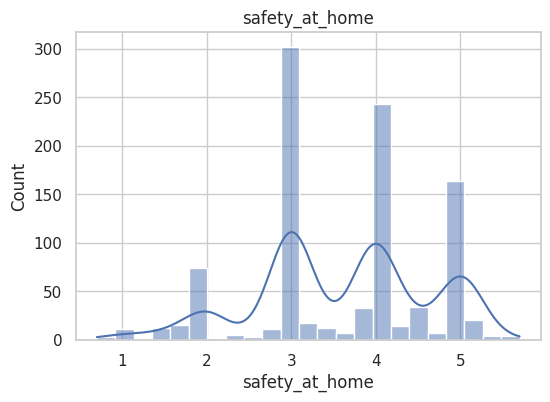

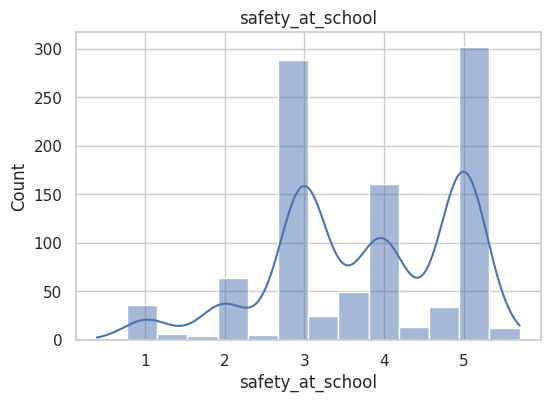

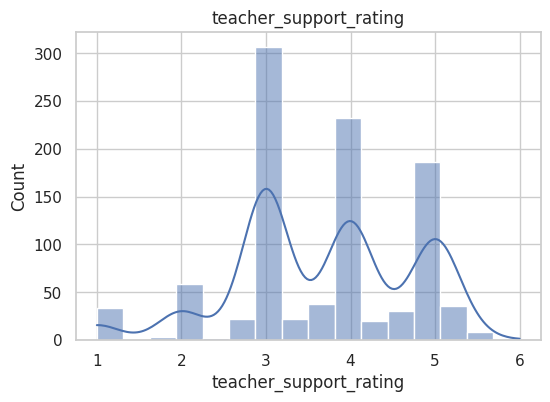

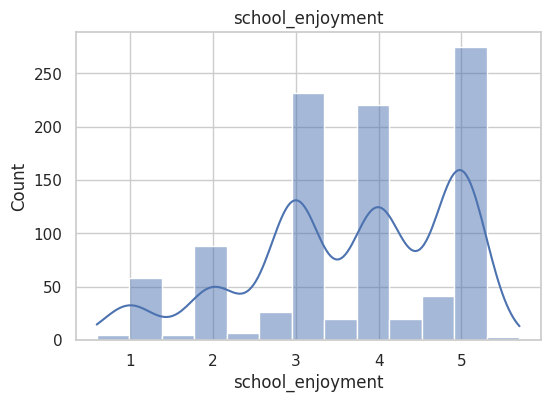

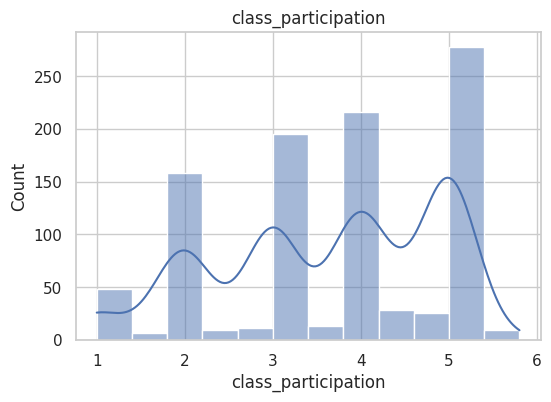

In [18]:
for col in numeric:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],
                 kde=True)

    plt.title(col)

    plt.savefig(f"{FIGURE_DIR}/{col}_hist.png",
                dpi=300,
                bbox_inches="tight")

    plt.show()

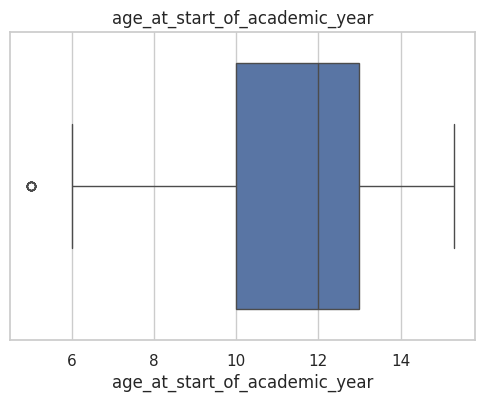

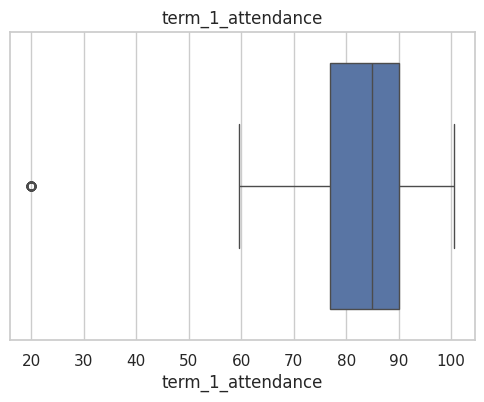

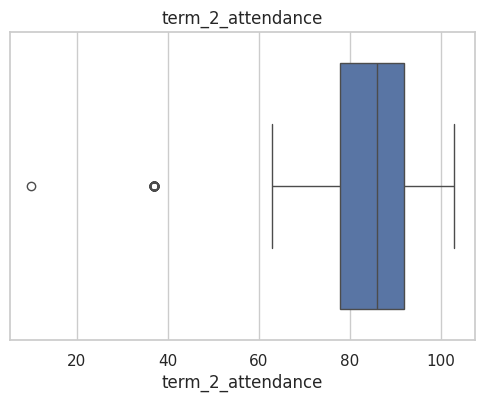

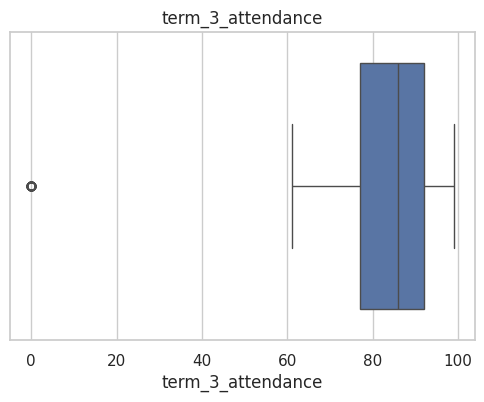

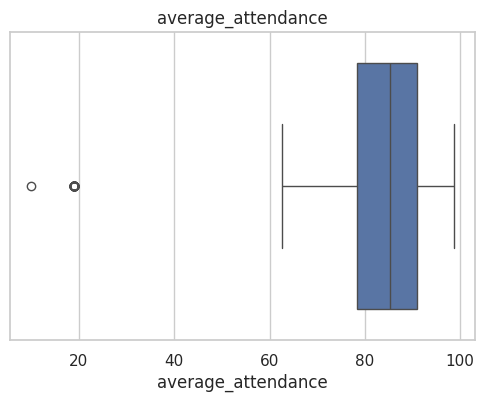

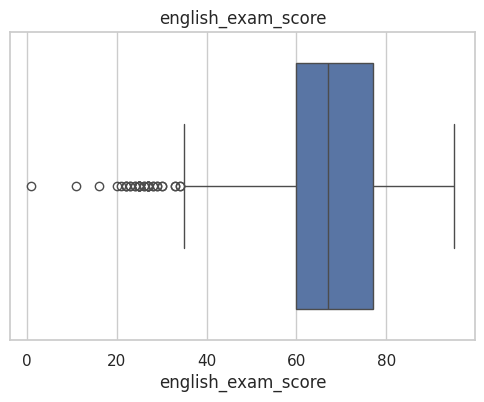

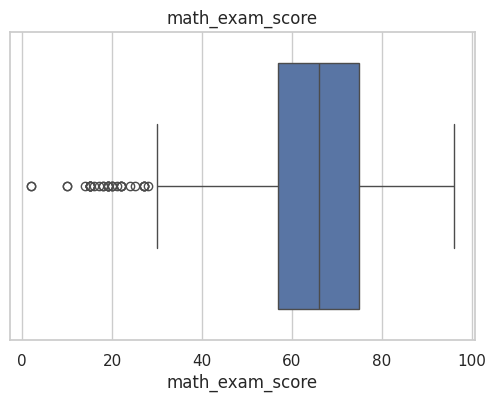

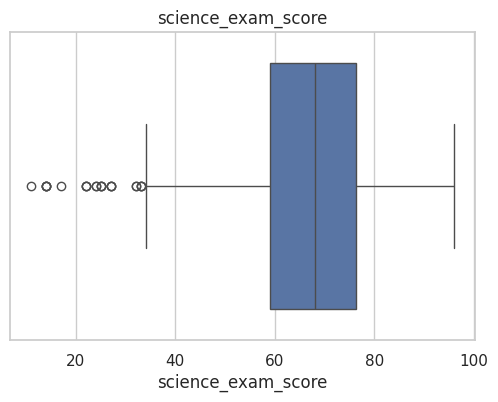

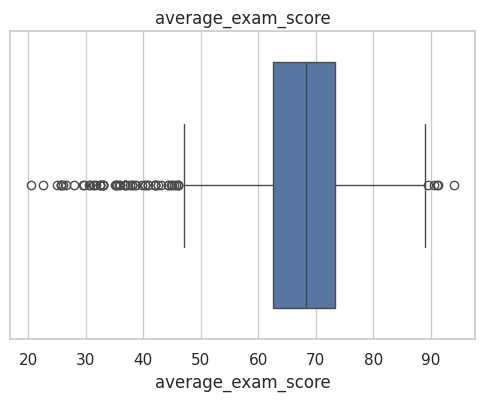

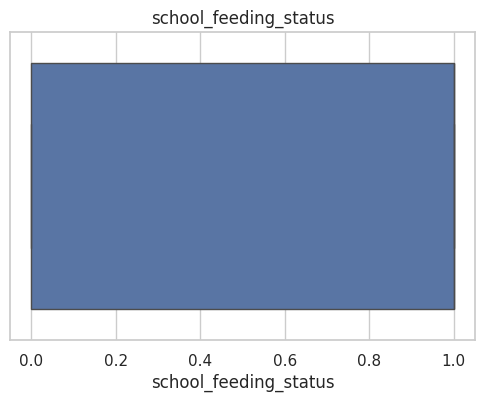

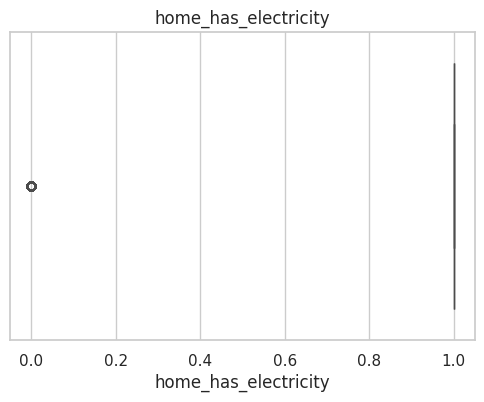

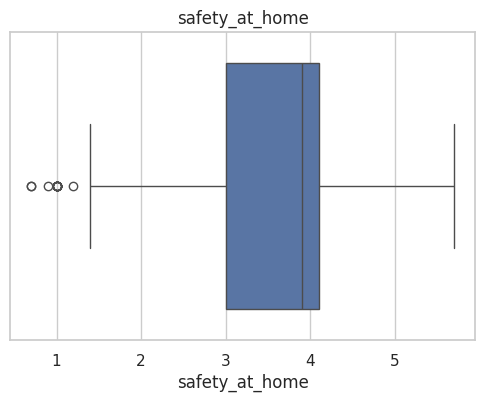

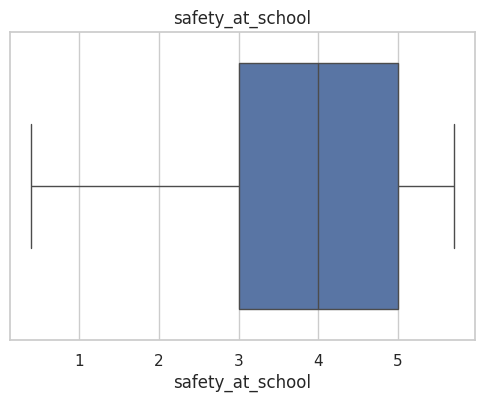

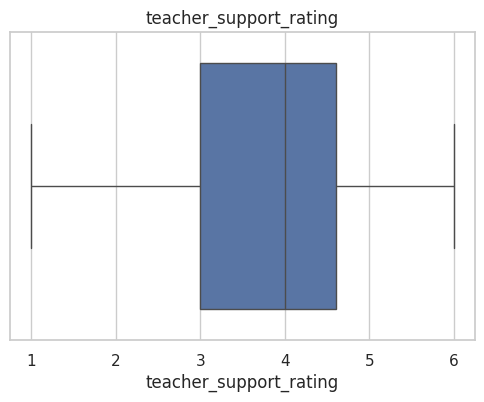

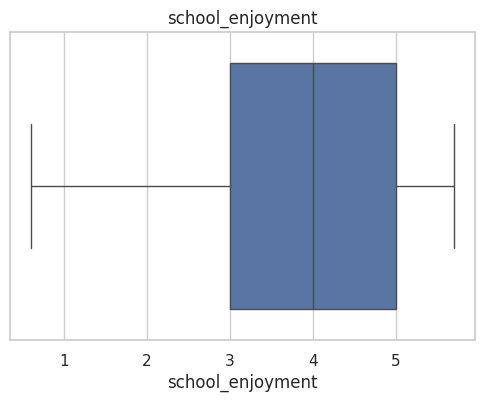

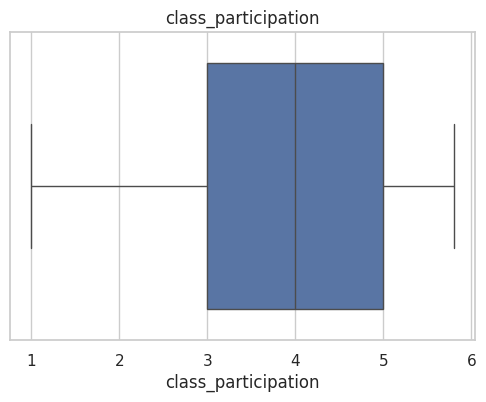

In [19]:
for col in numeric:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.savefig(f"{FIGURE_DIR}/{col}_boxplot.png",
                dpi=300,
                bbox_inches="tight")

    plt.show()

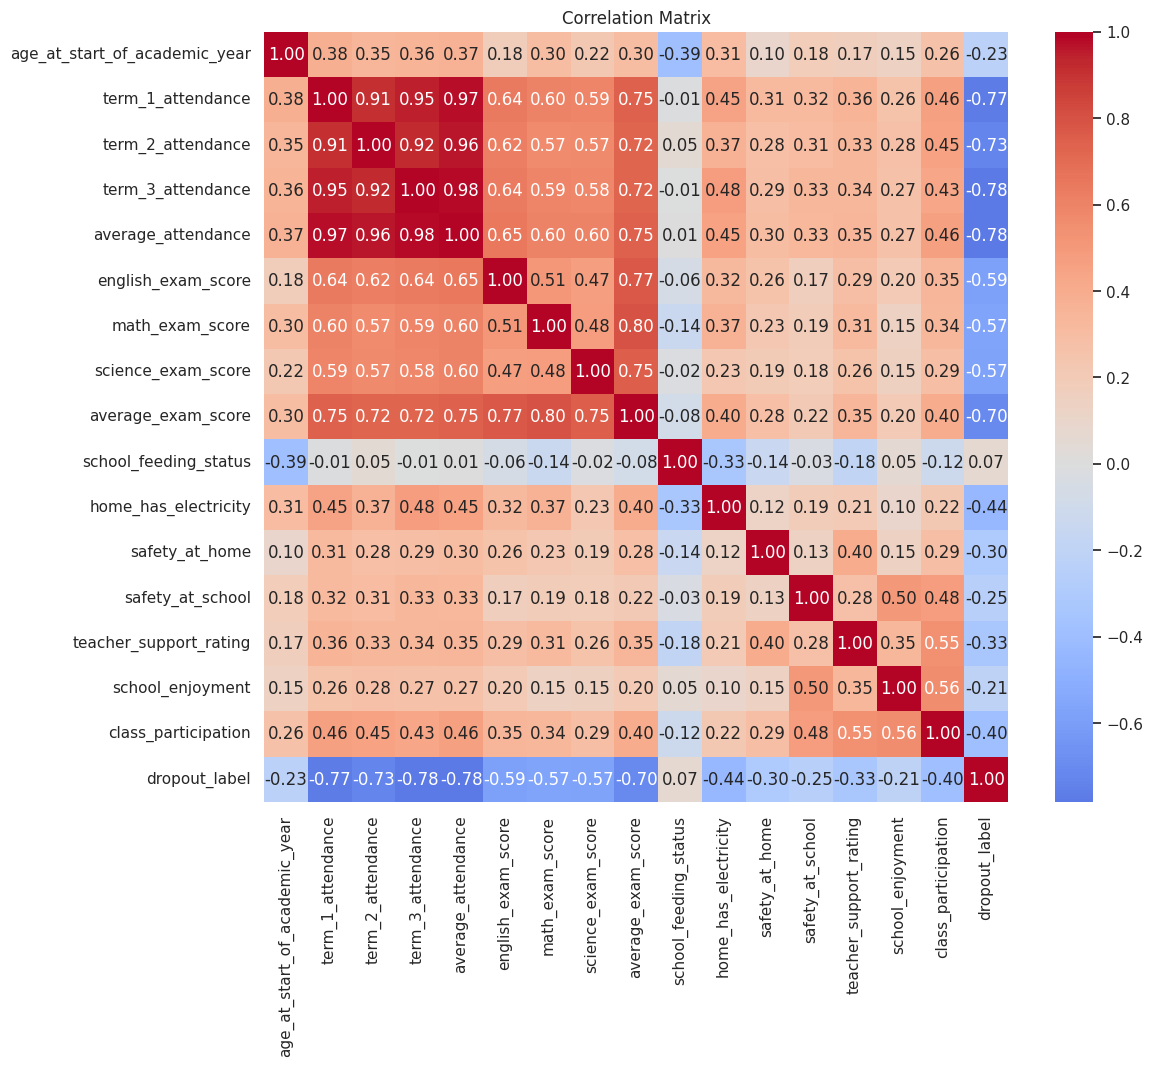

In [20]:
plt.figure(figsize=(12,10))

corr=df[numeric+[TARGET]].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig(f"{FIGURE_DIR}/correlation_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [21]:
corr_target=(
    corr[TARGET]
    .sort_values(ascending=False)
)

display(corr_target)

,dropout_label
dropout_label,1.000000
school_feeding_status,0.066187
school_enjoyment,-0.212370
age_at_start_of_academic_year,-0.227161
safety_at_school,-0.249119
safety_at_home,-0.300764
teacher_support_rating,-0.332532
class_participation,-0.399380
home_has_electricity,-0.438054
math_exam_score,-0.566168


In [22]:
categorical=df.select_dtypes(exclude=np.number).columns.tolist()

categorical

['school_code',
 'geographic_zone',
 'school_type',
 'data_source',
 'gender',
 'class_level',
 'grade_repetition_count',
 'social_studies_exam_score',
 'leap_beneficiary_status',
 'travel_time_to_school',
 'mode_of_transport_to_school',
 'govt_support',
 'parent_guardian_education_level',
 'parent_guardian_occupation',
 'no_of_siblings_in_school',
 'own_textbooks',
 'daily_study_hours_at_home',
 'missed_school_for_choreswork',
 'missed_school_due_to_illness',
 'barriers_to_regular_attendance',
 'family_income_level',
 'parent_attends_school_events',
 'behaviour_warnings_punishments',
 'extracurricular_activities']

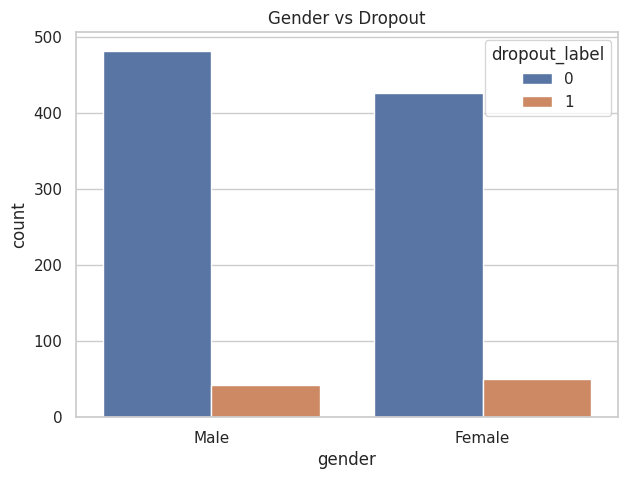

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue=TARGET
)

plt.title("Gender vs Dropout")

plt.savefig(f"{FIGURE_DIR}/gender_dropout.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

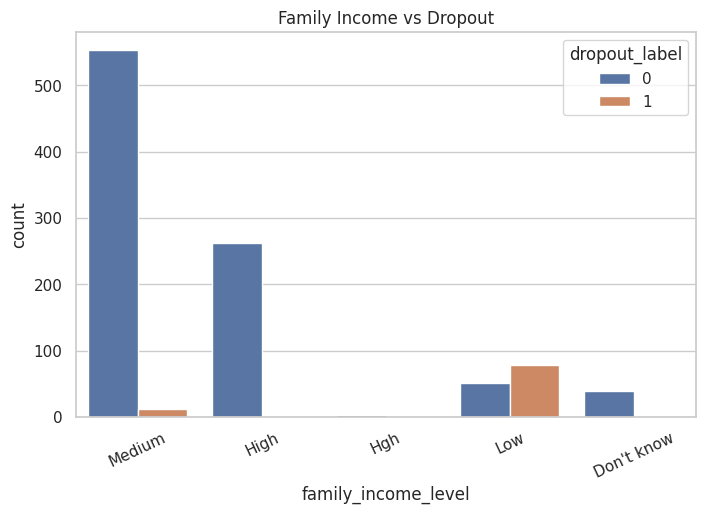

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="family_income_level",
    hue=TARGET
)

plt.xticks(rotation=25)

plt.title("Family Income vs Dropout")

plt.savefig(f"{FIGURE_DIR}/income_dropout.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

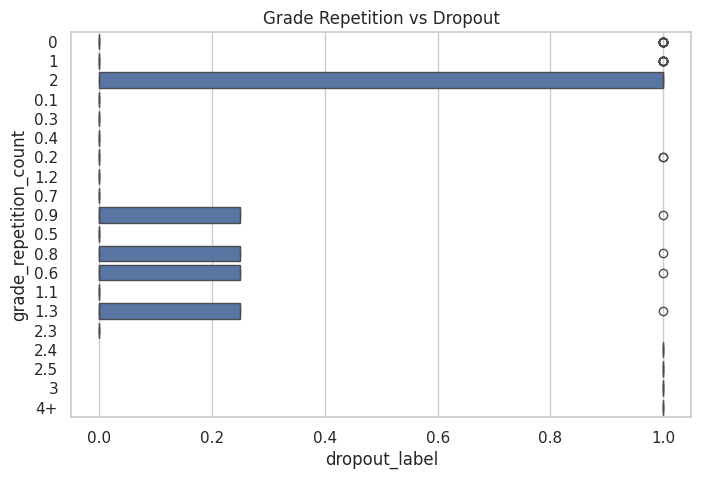

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x=TARGET,
    y="grade_repetition_count"
)

plt.title("Grade Repetition vs Dropout")

plt.savefig(f"{FIGURE_DIR}/grade_repetition_dropout.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [26]:
def chi_square_test(feature):

    table=pd.crosstab(df[feature],
                      df[TARGET])

    chi2,p,dof,expected=chi2_contingency(table)

    return p

In [27]:
results=[]

for col in categorical:

    p=chi_square_test(col)

    results.append([col,p])

chi_df=pd.DataFrame(
    results,
    columns=["Feature","P-Value"]
)

chi_df=chi_df.sort_values("P-Value")

display(chi_df)

,Feature,P-Value
20,family_income_level,8.218115e-102
6,grade_repetition_count,3.421423e-95
13,parent_guardian_occupation,1.615354e-73
15,own_textbooks,5.785615e-63
18,missed_school_due_to_illness,1.812116e-46
21,parent_attends_school_events,2.688311e-45
14,no_of_siblings_in_school,6.167582e-45
19,barriers_to_regular_attendance,1.291265e-44
16,daily_study_hours_at_home,6.580807e-38
22,behaviour_warnings_punishments,4.084690e-37


In [28]:
chi_df.to_csv(
    f"{PROJECT_DIR}/chi_square_results.csv",
    index=False
)

In [29]:
print("="*60)
print("EDA COMPLETE")
print("="*60)

print("✔ Dataset explored")
print("✔ Missing values analysed")
print("✔ Target analysed")
print("✔ Numerical distributions visualized")
print("✔ Correlation matrix generated")
print("✔ Chi-square tests completed")
print("✔ Figures saved")

EDA COMPLETE
✔ Dataset explored
✔ Missing values analysed
✔ Target analysed
✔ Numerical distributions visualized
✔ Correlation matrix generated
✔ Chi-square tests completed
✔ Figures saved
